# Visualize Confidence Intervals with Seaborn

Instead of using Python only for calculation, you could use it as a tool for *Exploratory Data Analysis* just like [Tableau](https://app.julie.academy/course/data-visualisation-e/data-visualisation-with-tableau-e) ! 😲 🤩 To do so, we can use a library called [`seaborn`](https://seaborn.pydata.org/). Let's check out a few features of it.


## What you will learn in this course 🧐🧐

* Use basic features of `seaborn`
* Create bar charts with `seaborn`
* Visualize confidence intervals

## Import classic libraries 📓

Let's first import classic libraries for Data Science: `pandas`, `numpy` and `seaborn`

In [ ]:
# Import of libraries
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt


# Exercice de la MasterClass

In [ ]:
# Chargement du fichier CSV
file_path = "km_traveled_all_transportations.csv"
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,type_of_transport,Km_traveled
0,25,uber,34
1,1,bike,30
2,24,uber,22
3,2,bike,17
4,6,bike,29


In [ ]:
# Suppression de la colonne "Unnamed: 0"
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [ ]:
print(df.head())
print("************************)")
print(df.dtypes)
print('************************')
print("Les valeurs manquantes")
print(df.isnull().sum())
print('*************************')
print(df.describe())

  type_of_transport  Km_traveled
0              uber           34
1              bike           30
2              uber           22
3              bike           17
4              bike           29
************************)
type_of_transport    object
Km_traveled           int64
dtype: object
************************
Les valeurs manquantes
type_of_transport    0
Km_traveled          0
dtype: int64
*************************
       Km_traveled
count    32.000000
mean     43.250000
std      19.354086
min      16.000000
25%      30.000000
50%      38.000000
75%      57.000000
max      87.000000


### Manipulation et Analyse des Données

In [ ]:
# Calculer la moyenne des kilomètres parcourus par type de transport
moyenne_km_transports = df.groupby("type_of_transport")["Km_traveled"].mean()

In [ ]:
# Calculer l’écart-type des kilomètres parcourus par type de transport
ecart_type_km_transports = df.groupby("type_of_transport")["Km_traveled"].std()

In [ ]:
# Trier les transports par distance moyenne parcourue (du plus petit au plus grand)
df_sorted = moyenne_km_transports.sort_values()
df_sorted

type_of_transport
bike    23.125
uber    40.375
car     49.875
bus     59.625
Name: Km_traveled, dtype: float64

In [ ]:
# Compter le nombre d'observations par type de transport
compte_transports = df["type_of_transport"].value_counts()
compte_transports


type_of_transport
uber    8
bike    8
bus     8
car     8
Name: count, dtype: int64

### Visualisations avec Seaborn

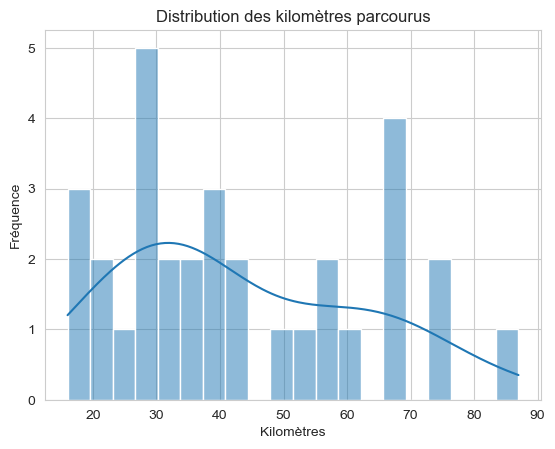

In [ ]:
# Observation de la fréquence des distances parcourures sans distingtion des types de transports
sns.histplot(df["Km_traveled"], bins=20, kde=True)
plt.title("Distribution des kilomètres parcourus")
plt.xlabel("Kilomètres")
plt.ylabel("Fréquence")
plt.show()

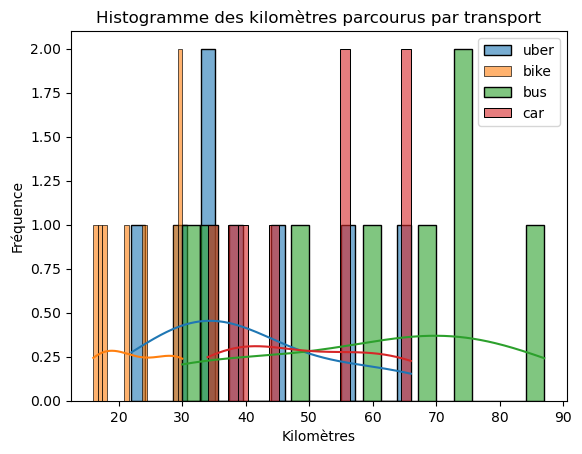

In [ ]:
# Pour prendre en compte la distribution par type de transport :
for transport in df["type_of_transport"].unique():
    subset = df[df["type_of_transport"] == transport]
    sns.histplot(subset["Km_traveled"], bins=20, kde=True, label=transport, alpha=0.6)

plt.title("Histogramme des kilomètres parcourus par transport")
plt.xlabel("Kilomètres")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


In [ ]:
df["type_of_transport"].unique()

array(['uber', 'bike', 'bus', 'car'], dtype=object)

In [ ]:
# Créer un histogramme des kilomètres parcourus
stats_transports = df.groupby("type_of_transport")["Km_traveled"].agg(["mean", "std"])
stats_transports = stats_transports.sort_values(by="mean")
print("\nStatistiques des distances par transport:")
print(stats_transports)

stats_transports = stats_transports.dropna()


Statistiques des distances par transport:
                     mean        std
type_of_transport                   
bike               23.125   5.962682
uber               40.375  14.441384
car                49.875  12.586132
bus                59.625  20.673914


C:\Users\Larbi\AppData\Local\Temp\ipykernel_46004\1759853434.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=stats_transports.index, y=stats_transports["mean"], ci=None)


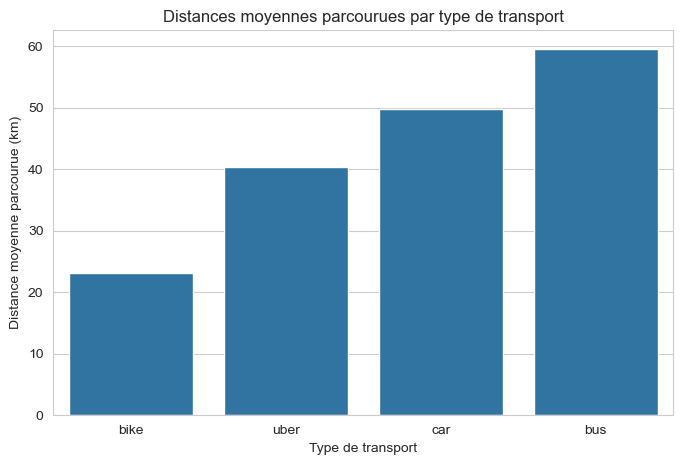

In [ ]:

# Visualisation des distances moyennes par type de transport
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=stats_transports.index, y=stats_transports["mean"], ci=None)
plt.xlabel("Type de transport")
plt.ylabel("Distance moyenne parcourue (km)")
plt.title("Distances moyennes parcourues par type de transport")
plt.savefig("test1.png")
plt.show()

In [ ]:
df.to_csv("test2.csv", sep = "s")

# Interprétation des intervalles :
### CI = 95%

- Signifie que dans 95% des cas, si nous refaisons l'expérience plusieurs fois, la vraie moyenne de la population sera comprise dans l'intervalle calculé.
- On utilise t.ppf(0.975, df=n-1) → Car on répartit 2.5% à gauche et 2.5% à droite pour un total de 95% au centre.
- Inconvénient : L'intervalle est plus large, donc moins précis.

### CI = 80%

- Signifie que dans seulement 80% des cas, la vraie moyenne de la population sera dans l'intervalle.
- On utilise t.ppf(0.90, df=n-1) → Car on répartit 10% à gauche et 10% à droite.
- Avantage : L'intervalle est plus étroit, donc plus précis.
- Inconvénient : Moins de certitude que la vraie moyenne y est incluse.

## Dataset

Now let's say we have the following dataset describing how many kilometers some people travel to commute to work every morning.

In [ ]:
# Build and Visualize Dataset
df = pd.read_csv("km_traveled_all_transportations.csv").iloc[:,1:]
df.head()

,type_of_transport,Km_traveled
0,uber,34
1,bike,30
2,uber,22
3,bike,17
4,bike,29


As you can see, our dataset is composed of `type_of_transport` and `km_traveled` per transport for each observation. Now what we need to know is the average `km_traveled` per transport. Therefore, we can use `.groupby` method in `pandas` that works exactly the same way as `GROUP BY` in SQL.

In [ ]:
# Percentage of conversions
df.groupby("type_of_transport").mean()

,Km_traveled
type_of_transport,
bike,23.125
bus,59.625
car,49.875
uber,40.375


Now the nice thing about this is that we can visualize our dataset using a library called `seaborn`. There is indeed one function called `catplot` (short for *categorical plot* for categorical data) which will give us automatically a bar chart per category including a confidence interval.

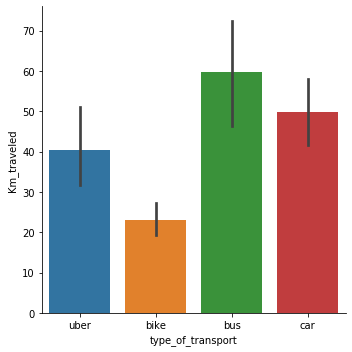

In [ ]:
# Visualisation of catplot version : conversion rate with 95% confidence level
sns.catplot(x="type_of_transport", y="Km_traveled", data = df, kind="bar")

As you can see the black lines at the end of each bar represent your confidence interval. Meaning your true mean lies between these lines. Now, let's see how we can reduce this confidence interval.

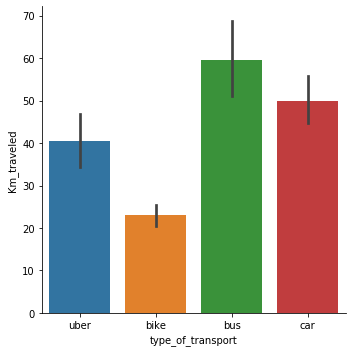

In [ ]:
### Let's reduce the confidence level to 85%
sns.catplot(x="type_of_transport", y="Km_traveled", data = df, kind="bar", ci=80)

Now we set up a confidence level $\alpha = 0.15$ and now we have way lower confidence intervals !

## Confidence intervals with category in columns

Now as a final note, your dataset won't always look like the one above. Sometimes, your categories will be in column just like the below dataset:

In [ ]:
df = pd.read_csv("src/km_traveled_per_transport.csv").iloc[:,1:]
df.head()

,bike,bus,car,uber
0,21,75,55,22
1,30,87,34,34
2,17,49,38,38
3,30,68,66,66
4,24,75,56,56


Now you will need to do a little bit more of manual work by selecting a `t-value` yourself and then specify it within a `.plot` function in `pandas`

👋  as a reminder, you need to compute the margin of error. Here is the formula for mean:

$$E = t \frac{s}{\sqrt{n}}$$

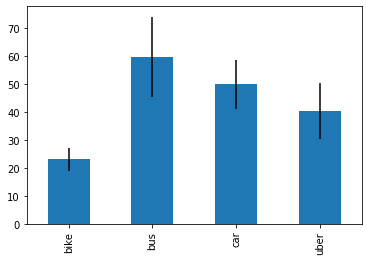

In [ ]:
# with confidence level at 0.9
t_value=1.96
sigma = df.std()
n = len(df)
E = t_value * sigma / np.sqrt(n)

df.groupby("type_of_transport").mean().plot(yerr=E, kind="bar")

## Resources 📚📚

- Simple barplot of column means using seaborn  - [https://bit.ly/2JLmv1Sv](https://stackoverflow.com/questions/50337237/simple-barplot-of-column-means-using-seaborn)

- pandas.DataFrame.plot - [https://bit.ly/30CAS](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html?highlight=plot#pandas.DataFrame.plot)

- Add 95% confidence intervals as error bars to pandas bar plot - [https://bit.ly/30CSAq](https://stackoverflow.com/questions/56776919/add-95-confidence-intervals-as-error-bars-to-pandas-bar-plot)
